# Resolution Analysis:
Floating point math can produce rounding errors that affect geometric computations. In addition, hand-drawn contours may have coordinates that are not perfectly aligned, leading to unexpected results when determining spatial relationships. 

There are several ways to address these issues. 
One way is to round the coordinates of contour points to a specified resolution before performing geometric operations.  However, this can result in invalid geometries if not done carefully.  Invalid geometries can be fixed using the shapely.make_valid() function, and then select the largest resulting polygon.

Another approach is to use the shapely.snap() function to snap points that are within a certain tolerance to each other. This can help ensure that points that are meant to be coincident are treated as such, reducing the likelihood of errors in geometric computations. The snap should employ a grid of points at the desired resolution.  This will ensure that all points are aligned to the grid, allowing all contours to be compared at the same resolution.  The snap tolerance should be half the grid spacing to ensure that points are snapped to the nearest grid point.

Another tool that can be used is the shapely.simplify() function, which reduces the number of points in a geometry while preserving its overall shape. This can help reduce the complexity of geometric computations and improve performance.  The tolerance for simplification should be set to the desired resolution.


## Setup

### Imports

#### Type imports

In [1]:
from typing import List, Tuple

In [2]:
from math import radians, cos, sin
import logging


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import shapely
from shapely.plotting import plot_polygon, plot_line


In [4]:
#from types_and_classes import TRANSVERSE_PRECISION, SLICE_INDEX_PRECISION
from types_and_classes import PRECISION
from types_and_classes import ContourPointsType

from types_and_classes import InvalidContour

from debug_tools import plot_ab

In [5]:
%matplotlib inline

In [6]:
# Configure logging if not already configured
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


In [7]:
TRANSVERSE_PRECISION = 0.01  # The default resolution in the transverse plane in cm
SLICE_INDEX_PRECISION = 0.01  # The default precision for slice indexes in cm


## Rounding Functions

### `round_contour_points`
- Rounds the coordinates of contour points to a specified precision.

In [8]:
def round_contour_points(contour_points: ContourPointsType,
                         resolution=TRANSVERSE_PRECISION) -> ContourPointsType:
    '''Round contour points to the specified resolution.

    Rounds the x and y coordinates of all contour points to the nearest
    resolution increment. Z coordinates are left unchanged as they typically
    represent slice positions that should remain precise.

    Args:
        contour_points (ContourPointsType): A list of length 2 or three tuples
            of float containing the (x, y) or (x, y, z) coordinates that define
            a contour.
        resolution (float, optional): The resolution increment to round to in
            cm. Defaults to TRANSVERSE_PRECISION.

    Returns:
        ContourPointsType: A new list of contour points with x and y
            coordinates rounded to the specified resolution.

    '''
    if not contour_points:
        logger.debug("No contour points to round")
        return []

    if resolution <= 0:
        raise ValueError("Resolution must be a positive number")
    # Determine the number of decimal places for rounding based on resolution
    decimal_places = -int(np.log10(resolution)) + 1
    logger.debug(f"Rounding to resolution: {resolution} cm, decimal places: {decimal_places}")

    # convert contour_points to numpy array for easier manipulation
    points = np.array(contour_points)
    original_points = points.copy()

    # convert x and y coordinates to multiple of resolution
    points[:, 0] = (points[:, 0] // resolution) * resolution
    points[:, 1] = (points[:, 1] // resolution) * resolution
    # Round x and y coordinates to avoid floating point precision issues
    points[:, 0] = np.round(points[:, 0], decimals=decimal_places)
    points[:, 1] = np.round(points[:, 1], decimals=decimal_places)

    # Z coordinates ([:, 2]) are left unchanged

    # convert back to list of tuples
    rounded_points = points.tolist()

    # Difference between the original and rounded points
    differences = np.abs(np.array(rounded_points) - original_points)
    logger.debug(f"Max difference (x, y): {np.max(differences[:, :2], axis=0)}")
    logger.debug(f"Average difference (x, y): {np.mean(differences[:, :2], axis=0)}")

    return rounded_points

#### Quick demo of `round_contour_points`


Original points: (0.12345, 1.23456), (2.34567, -0.98765), (3.14159, 2.71828)
round_contour_points returned: [[0.0, 1.2], [2.2, -1.0], [3.0, 2.6]]
Rounded points (resolution=0.2): (0.0, 1.2), (2.2, -1.0), (3.0, 2.6)


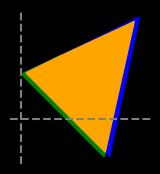

In [9]:
sample_contour = [(0.12345, 1.23456), (2.34567, -0.98765), (3.14159, 2.71828)]
example_resolution = 0.2  # Example resolution for rounding
print(f'Original points: {", ".join(str(p) for p in sample_contour)}')

ret = round_contour_points(sample_contour, resolution=example_resolution)
print(f'round_contour_points returned: {ret}')

# Compute and show rounded result (round_contour_points does not return the rounded points)
arr = np.array(sample_contour)
arr[:, 0] = (arr[:, 0] // example_resolution) * example_resolution
arr[:, 1] = (arr[:, 1] // example_resolution) * example_resolution
decimal_places = -int(np.log10(example_resolution)) + 1
# Round x and y coordinates to avoid floating point precision issues
arr[:, 0] = np.round(arr[:, 0], decimals=decimal_places)
arr[:, 1] = np.round(arr[:, 1], decimals=decimal_places)

rounded_points = [tuple(float(x) for x in row) for row in arr]

print(f'Rounded points (resolution={example_resolution}): {", ".join(str(p) for p in rounded_points)}')

# Visual comparison between original and rounded polygons
poly_orig = shapely.Polygon(sample_contour)
poly_rounded = shapely.Polygon(rounded_points)
ax = plot_ab(poly_orig, poly_rounded)

### `make_coordinates_valid`
- Rounding the coordinates of of a polygon can result in an invalid polygon 
when there are closely spaced "noisy" coordinates.  
- This can be fixed using the shapely.make_valid() function, and then select the largest resulting polygon.


In [10]:
def make_coordinates_valid(contour_points: ContourPointsType)->ContourPointsType:
    '''Fix invalid geometries resulting from rounding coordinates.
    using shapely.make_valid() and return the largest polygon.

    This function applies shapely.make_valid() to the clean up small loops,
    crosses, or duplicated points in the rounded contour points. If the
    result contains multiple polygonal parts (MultiPolygon or GeometryCollection),
    the largest polygon by area is selected and returned. If no polygonal part
    is found, the function returns the geometry produced by make_valid().

    Args:
        geom: A shapely geometry that may be invalid.

    Returns:
        The largest shapely Polygon found after making the geometry valid, or
        the make_valid() result if only one polygonal part exists.
    '''
    if not contour_points:
        logger.debug("No contour points to round")
        return []

    original_polygon = shapely.Polygon(contour_points)

    valid_polygon = shapely.make_valid(original_polygon)

    # If already a single polygon, return it
    if isinstance(valid_polygon, shapely.Polygon):
        logger.debug(f'Returned geometry is a Polygon with area '
                     f'{valid_polygon.area}')
        return valid_polygon

    # Collect polygons parts from the made-valid geometry
    if isinstance(valid_polygon, (shapely.MultiPolygon,
                                  shapely.GeometryCollection)):
        polygons = []
        for polygon in valid_polygon.geoms:
            # Skip non-polygon geometries
            if isinstance(polygon, shapely.Polygon):
                polygons.append([polygon, polygon.area])
        if polygons:
            polygons.sort(key=lambda p: p[1], reverse=True)
            largest = polygons[0][0]
            logger.debug(f'Found {len(polygons)} polygon parts, returning '
                         f'largest area {polygons[0][1]}')

    # if no polygon parts found, contour_points do not form a valid polygon
    else:
        raise InvalidContour('Coordinates do not form a valid polygon.')

    return largest

#### Quick demo of `make_coordinates_valid`

Original points: (0.12345, 1.23456), (2.34567, -0.98765), (2.44567, -0.98765), (2.2567, -0.99765), (2.45567, -0.98765), (2.38, -0.95), (2.39, -0.9432), (3.14159, 2.71828)
Rounded points: [0.0, 1.2], [2.2, -1.0], [2.4, -1.0], [2.2, -1.0], [2.4, -1.0], [2.2, -1.0], [2.2, -1.0], [3.0, 2.6]
Original polygon is valid: True, area: 5.068548
Rounded polygon is valid: False, area: 4.840000
Corrected polygon is valid: True, area: 4.840000


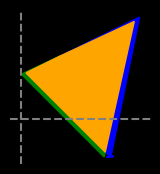

In [11]:
# Simple example containing a small loop
sample_contour = [(0.12345, 1.23456), (2.34567, -0.98765), (2.44567, -0.98765),
                  (2.2567, -0.99765), (2.45567, -0.98765), (2.38000, -0.95000),
                  (2.3900, -0.9432),(3.14159, 2.71828)]
example_resolution = 0.2  # Example resolution for rounding

rounded = round_contour_points(sample_contour, resolution=example_resolution)
print(f'Original points: {", ".join(str(p) for p in sample_contour)}')
print(f'Rounded points: {", ".join(str(p) for p in rounded)}')
original_polygon = shapely.Polygon(sample_contour)
print(f'Original polygon is valid: {original_polygon.is_valid}, '
      f'area: {original_polygon.area:.6f}')
shapely_poly_rounded = shapely.Polygon(rounded)
print(f'Rounded polygon is valid: {shapely_poly_rounded.is_valid}, '
      f'area: {shapely_poly_rounded.area:.6f}')

# Create polygons from the rounded coordinates and apply make_coordinates_valid
poly_rounded = shapely.Polygon(rounded)
valid_polygon = make_coordinates_valid(rounded)

print(f'Corrected polygon is valid: {valid_polygon.is_valid}, '
      f'area: {valid_polygon.area:.6f}')

# Visual comparison between the rounded polygon and the made-valid geometry
ax = plot_ab(original_polygon, valid_polygon)

There seems to be a problem with the shapely.relates function. It is not returning the correct relationship between the two polygons.

In [ ]:
def circle_points(radius: float, offset_x: float = 0, offset_y: float = 0,
                  num_points: int = 16, precision=PRECISION,
                  z:float=None)->list[tuple[float, float]]:
    deg_step = radians(360/num_points)
    degree_points = np.arange(stop=radians(360), step=deg_step)
    if radius == 0:
        radius = 10**(-precision)
    x_coord = np.array([round(radius*sin(d), precision) for d in degree_points])
    y_coord = np.array([round(radius*cos(d), precision) for d in degree_points])
    x_coord = x_coord + offset_x
    y_coord = y_coord + offset_y
    if z is not None:
        z = float(z)
        coords = [(x,y,z) for x,y in zip(x_coord,y_coord)]
    else:
        coords = list(zip(x_coord,y_coord))
    return coords

In [ ]:
circle6 = shapely.Polygon(circle_points(3))
circle4_offset = shapely.Polygon(circle_points(2, offset_x=2))
cropped_circle = shapely.intersection(circle6, circle4_offset)


In [ ]:
ax = plot_ab(circle6, cropped_circle)

In [ ]:
circle6.relate(cropped_circle)

`'212111212'` is a rather odd relationship code. 
It says that the two polygons both have parts that are exterior to the other, but the difference between cropped_circle and circle6 is an empty polygon.

In [ ]:
dif = cropped_circle - circle6
dif.area


In [ ]:
shapely.get_coordinates(dif).tolist()

In [ ]:
cropped_circle.relate(circle6)

The transposed relation produces the same result, which is also incorrect.

## First guess is a rounding error

In [ ]:
simplified = shapely.simplify(cropped_circle, 10**-PRECISION)
simplified

In [ ]:
circle6.relate(simplified)

In [ ]:
snapped = shapely.snap(cropped_circle, circle6, 10**-PRECISION)
snapped

In [ ]:
circle6.relate(snapped)

In [ ]:
simplified = shapely.simplify(cropped_circle, 10**-2)
circle6.relate(simplified)

In [ ]:
snapped = shapely.snap(cropped_circle, circle6, 10**-2)
circle6.relate(snapped)

## If precision is set to 2, the result is correct

In [ ]:
circle6 = shapely.Polygon(circle_points(3, precision=2))
circle4_offset = shapely.Polygon(circle_points(2, offset_x=2, precision=2))
cropped_circle = shapely.intersection(circle6, circle4_offset)

circle6.relate(cropped_circle)

## Try removing the rounding using `simplify` or `snap`

In [ ]:
def circle_points_no_round(radius: float,
                           offset_x: float = 0, offset_y: float = 0,
                           num_points: int = 16)->list[tuple[float, float]]:
    deg_step = radians(360/num_points)
    degree_points = np.arange(stop=radians(360), step=deg_step)
    x_coord = np.array([radius*sin(d) for d in degree_points])
    y_coord = np.array([radius*cos(d) for d in degree_points])
    x_coord = x_coord + offset_x
    y_coord = y_coord + offset_y
    coords = list(zip(x_coord,y_coord))
    return coords

In [ ]:
circle6 = shapely.Polygon(circle_points_no_round(3))
circle4_offset = shapely.Polygon(circle_points_no_round(2, offset_x=2))
cropped_circle = shapely.intersection(circle6, circle4_offset)

circle6.relate(cropped_circle)

In [ ]:
simplified = shapely.simplify(cropped_circle, 10**-2)
circle6.relate(simplified)

In [ ]:
snapped = shapely.snap(cropped_circle, circle6, 10**-2)
circle6.relate(snapped)